This notebook reads lidar and camera data from UR bag and converts it into a format that can be used by the evaluate_flow_calibration.py script

In [55]:
import numpy as np
import cv2
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

from mcap_protobuf.decoder import DecoderFactory
from mcap.reader import make_reader

from tkCloudProtoConverter import protoCloudToNumpy, protoCloudToPcdFile

In [ ]:
DATA_FOLDER = Path("/data")
LIDAR_TOPIC = "/lidar_fc/cloud"
CAMERA_TOPIC = "/camera_fl/image"
CALIBS_FILE = Path("../ur.autopilot/calib_manager.yaml")

In [ ]:
with open(self.filepath, "r") as file:
    data = yaml.safe_load(file)
intrinsics = data["intrinsics"]
extrinsics = data["extrinsics"]

In [56]:
f = open(DATA_FOLDER / "ur/short.mcap", "rb")
reader = make_reader(f, decoder_factories=[DecoderFactory()])

last_pcd = None
last_img = None
for schema, channel, message, proto_msg in tqdm(
        reader.iter_decoded_messages(topics=[LIDAR_TOPIC, CAMERA_TOPIC])
    ):
    if channel.topic == CAMERA_TOPIC:
        nparr = np.frombuffer(proto_msg.data, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        last_img = img
    elif channel.topic == LIDAR_TOPIC:
        last_pcd = protoCloudToPcdFile(proto_msg)

785it [00:05, 146.16it/s]


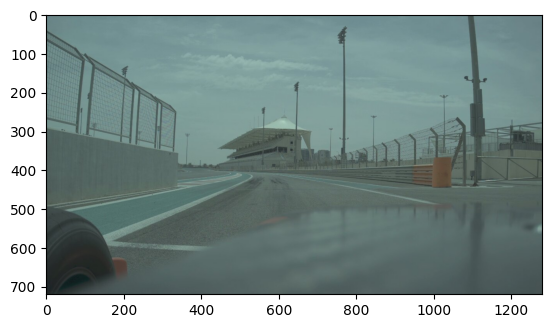

In [30]:
plt.imshow(img)
plt.show()

In [48]:
last_pcd[0, 0]

2.703190565109253

In [ ]:
np.array([1, 2, 3], dtype=">f4").tobytes()

b'?\x80\x00\x00@\x00\x00\x00@@\x00\x00'
